---

# LINE STYLES

---

>---
>
>You can change the **line style** with the `linestyle`, `linewidth`, and `color` arguments.
>
>- Common line styles are "solid", "dashed", or "dotted"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', 
                 parse_dates=['period_begin'])

df = (df
    .pivot_table(index='period_begin', 
                 columns='region_name', 
                 values='median_active_list_price', 
                 aggfunc='mean')
    .assign(ca_average = lambda x: x.mean(axis=1).round())
    .resample('QE').mean().round()
)

display(df.head())
df.info(memory_usage='deep')

region_name,Los Angeles,San Diego,San Francisco,ca_average
period_begin,,,,
2017-03-31,630557.0,637701.0,1263499.0,843919.0
2017-06-30,650077.0,652195.0,1259083.0,853785.0
2017-09-30,651898.0,646279.0,1276378.0,858185.0
2017-12-31,655576.0,645082.0,1300292.0,866983.0
2018-03-31,686360.0,660420.0,1333339.0,893373.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2017-03-31 to 2022-06-30
Freq: QE-DEC
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    22 non-null     float64
 1   San Diego      22 non-null     float64
 2   San Francisco  22 non-null     float64
 3   ca_average     22 non-null     float64
dtypes: float64(4)
memory usage: 880.0 bytes


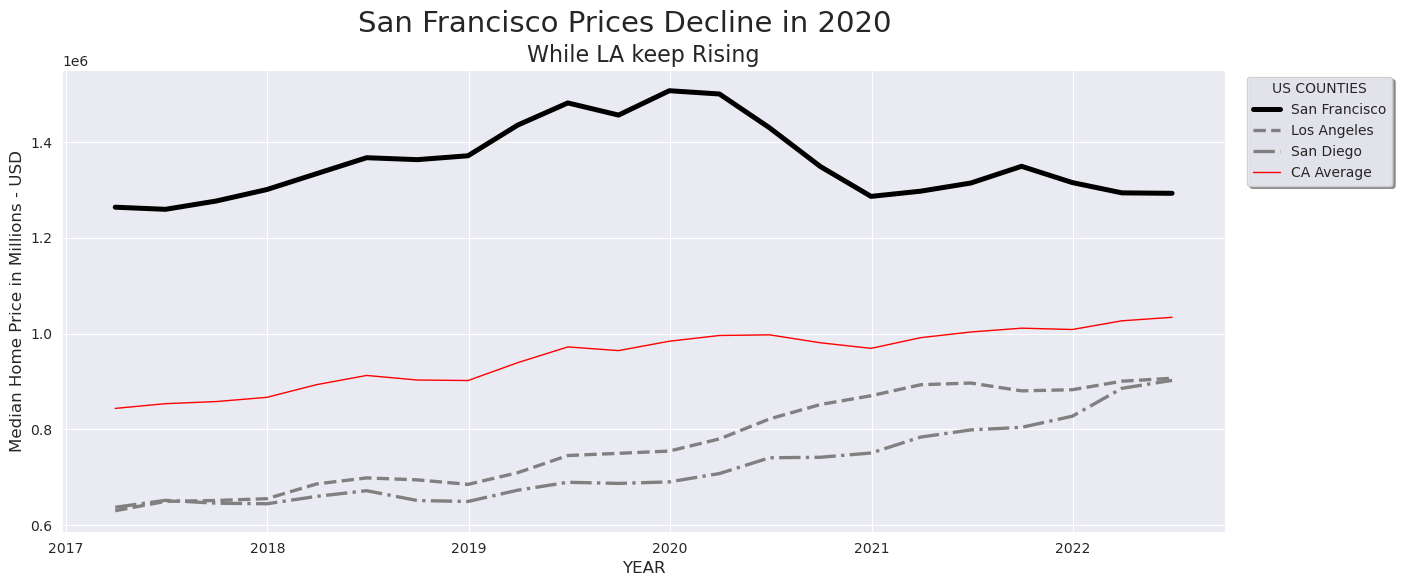

In [17]:
# Now it's time to plot...
sns.set_style('darkgrid')

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df['San Francisco'], label='San Francisco', 
        color='black', 
        linestyle='-', 
        linewidth=3.6)

ax.plot(df['Los Angeles'], label='Los Angeles', 
        color='gray', 
        linestyle='--', 
        linewidth=2.4)

ax.plot(df['San Diego'], label='San Diego', 
        color='gray', 
        linestyle='-.', 
        linewidth=2.4)

ax.plot(df['ca_average'], label='CA Average',
        color='red', 
        linestyle='-',
        linewidth=1)


fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21)
ax.set_title('While LA keep Rising', fontsize=16)
ax.set_xlabel('YEAR', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)
ax.legend(bbox_to_anchor=(1.15, 1),
          title='US COUNTIES',
          fancybox=True,
          shadow=True,
          framealpha=0.9,
         )
plt.show()